In [ ]:
import csv
import pandas as pd
import seaborn as sns

file_path = "user-courses-review-test-set.csv"

data_list = []

EXPECTED_COLUMNS = 4

with open(file_path, mode='r', newline='', encoding='utf-8') as file:
    reader = csv.reader(file)
    header = next(reader)

    for row in reader:
        if len(row) == EXPECTED_COLUMNS:
            data_list.append(row)
        else:
            print(f"skipping row {reader.line_num} : {row}")

data = pd.DataFrame(data_list, columns=header)
print(data)

                                     course_name  \
0                       Advanced Microsoft Excel   
1             Agile and Scrum Project Management   
2           AI Applications for Business Success   
3           AI Applications for Business Success   
4          Building a 3-Statement Model in Excel   
..                                           ...   
149  Web Scraping and API Fundamentals in Python   
150                     Who Does What in Finance   
151                     Who Does What in Finance   
152                     Who Does What in Finance   
153                     Who Does What in Finance   

                                          lecture_name review_rating  \
0              F1 to F12 - Using Excel's Function Keys             5   
1                     Agile vs Waterfall - Conclusions             1   
2                            Correlation vs. Causation             3   
3                            Correlation vs. Causation             3   
4    Calculatin

In [16]:
data_types = data.dtypes
if data['review_rating'].dtype == 'object':
    data['review_rating'] = pd.to_numeric(data['review_rating'], errors='coerce')

    new_data_types = data.dtypes
    missing_values = data.isnull().sum()

data_types, new_data_types, missing_values

(course_name       object
 lecture_name      object
 review_rating     object
 review_comment    object
 dtype: object,
 course_name       object
 lecture_name      object
 review_rating      int64
 review_comment    object
 dtype: object,
 course_name       0
 lecture_name      0
 review_rating     0
 review_comment    0
 dtype: int64)

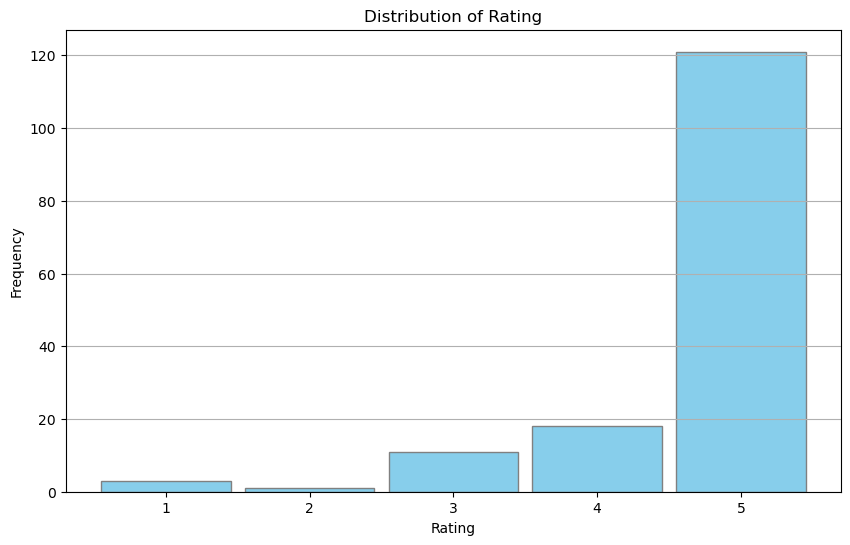

count    154.000000
mean       4.642857
std        0.805849
min        1.000000
25%        5.000000
50%        5.000000
75%        5.000000
max        5.000000
Name: review_rating, dtype: float64

In [17]:
import matplotlib.pyplot as plt

review_rating_stats = data['review_rating'].describe()

plt.figure(figsize=(10, 6))
plt.hist(data['review_rating'].dropna(), bins=range(1, 7), align='left', rwidth=0.9, color='skyblue', edgecolor='gray')
plt.title('Distribution of Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.xticks(range(1, 6))
plt.grid(axis='y')
plt.show()

review_rating_stats

In [18]:
clean_data = data.dropna()

new_shape = clean_data.shape

clean_data['comment_length'] = clean_data['review_comment'].apply(len)

correlation = clean_data[['review_rating', 'comment_length']].corr()

new_shape, correlation

((154, 4),
                 review_rating  comment_length
 review_rating        1.000000       -0.130977
 comment_length      -0.130977        1.000000)

In [19]:
import re

patterns = {
    "positive_emphasis": re.compile(r'\b(great|good|excellent|amazing|love|best|awesome|fantastic)\b', re.IGNORECASE),
    "negative_emphasis": re.compile(r'\b(bad|terrible|awful|poor|worst|hate|disappoint)\b', re.IGNORECASE),
    "question": re.compile(r'\?'),
    "exclamation": re.compile(r'\!'),
    "capital_words": re.compile(r'\b[A-Z]{2,}\b')
}

pattern_counts = {key: 0 for key in patterns}

for review in clean_data['review_comment']:
    for key, pattern in patterns.items():
        if re.search(pattern, review):
            pattern_counts[key] += 1

pattern_counts

{'positive_emphasis': 82,
 'negative_emphasis': 1,
 'question': 0,
 'exclamation': 20,
 'capital_words': 9}

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
import string

def clean_text(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

clean_data.loc[:, 'review_comment'] = clean_data.loc[:, 'review_comment'].apply(clean_text)

x = clean_data.loc[:, 'review_comment']
y = clean_data.loc[:, 'review_comment']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [21]:
vectorizer = TfidfVectorizer(stop_words='english')

model = MultinomialNB()

text_clf = make_pipeline(vectorizer, model)

text_clf.fit(x_train, y_train)

y_pred = text_clf.predict(x_test)

report = classification_report(y_test, y_pred)

conf_matrix = confusion_matrix(y_test, y_pred)

report, conf_matrix

C:\Users\2023\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\2023\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\2023\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


('                                                                                                                                                                                                                                                                                                                                                                                                                                 precision    recall  f1-score   support\n\n                                                                                                                                                                                                                                                                                                                                                                                                                                      0.00      0.00      0.00         1\n                                                                                

In [22]:
from sklearn.utils import resample

df_majority = clean_data[clean_data.review_rating == 5]
df_minority = clean_data[clean_data.review_rating < 5]

df_minority_upsampled = resample(df_minority, 
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

df_upsampled = pd.concat([df_majority, df_minority_upsampled])

df_upsampled.review_rating.value_counts()

review_rating
5    121
4     73
3     34
1     12
2      2
Name: count, dtype: int64

In [23]:
x_sampled = df_upsampled['review_comment']
y_sampled = df_upsampled['review_rating']

x_train_upsampled, x_test_upsampled, y_train_upsampled, y_test_upsampled = train_test_split(
    x_sampled, y_sampled, test_size=0.2, random_state=42)

text_clf_upsampled = make_pipeline(vectorizer, model)
text_clf_upsampled.fit(x_train_upsampled, y_train_upsampled)

y_pred_upsampled = text_clf_upsampled.predict(x_test_upsampled)

report_upsampled = classification_report(y_test_upsampled, y_pred_upsampled)

conf_matrix_upsampled = confusion_matrix(y_test_upsampled, y_pred_upsampled)

report_upsampled, conf_matrix_upsampled

C:\Users\2023\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\2023\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\2023\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


('              precision    recall  f1-score   support\n\n           1       1.00      0.33      0.50         3\n           2       0.00      0.00      0.00         1\n           3       1.00      0.33      0.50         6\n           4       0.75      0.92      0.83        13\n           5       0.77      0.88      0.82        26\n\n    accuracy                           0.78        49\n   macro avg       0.70      0.49      0.53        49\nweighted avg       0.79      0.78      0.75        49\n',
 array([[ 1,  0,  0,  0,  2],
        [ 0,  0,  0,  0,  1],
        [ 0,  0,  2,  1,  3],
        [ 0,  0,  0, 12,  1],
        [ 0,  0,  0,  3, 23]], dtype=int64))

C:\Users\2023\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\2023\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\2023\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


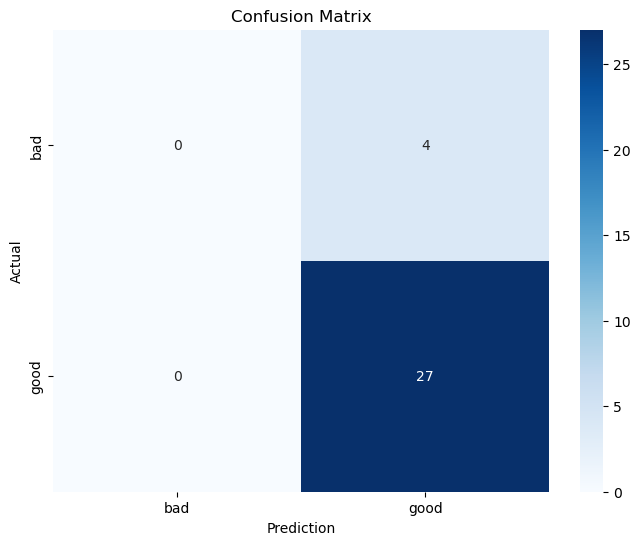

,precision,recall,f1-score,support
bad,0.000000,0.000000,0.000000,4.000000
good,0.870968,1.000000,0.931034,27.000000
accuracy,0.870968,0.870968,0.870968,0.870968
macro avg,0.435484,0.500000,0.465517,31.000000
weighted avg,0.758585,0.870968,0.810901,31.000000


In [29]:
def binary_rating(rating):
    if rating >= 4:
        return 'good'
    else:
        return 'bad'

binary_data = clean_data.copy()
binary_data['review_rating'] = binary_data['review_rating'].apply(binary_rating)

x_binary = binary_data['review_comment']
y_binary = binary_data['review_rating']

x_train_binary, x_test_binary, y_train_binary, y_test_binary = train_test_split(
    x_binary, y_binary, test_size=0.2, random_state=42)

text_clf_binary = make_pipeline(vectorizer, model)
text_clf_binary.fit(x_train_binary, y_train_binary)

y_pred_binary = text_clf_binary.predict(x_test_binary)

report_binary = classification_report(y_test_binary, y_pred_binary, output_dict=True)

conf_matrix_binary = confusion_matrix(y_test_binary, y_pred_binary)

report_binary_df = pd.DataFrame(report_binary).transpose()

plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['bad', 'good'], yticklabels=['bad', 'good'])
plt.ylabel('Actual')
plt.xlabel('Prediction')
plt.title('Confusion Matrix')
plt.show()

report_binary_df

In [ ]:
df_majority_binary = binary_data[binary_data.review_rating == 'good']
df_minority_binary = binary_data[binary_data.review_rating == 'bad']
    
df_minority_upsampled_binary = resample(df_minority_binary, 
                                 replace=True,
                                 n_samples=len(df_majority_binary),
                                 random_state=42)

df_upsampled_binary = pd.concat([df_majority_binary, df_minority_upsampled_binary])

df_upsampled.review_rating.value_counts()